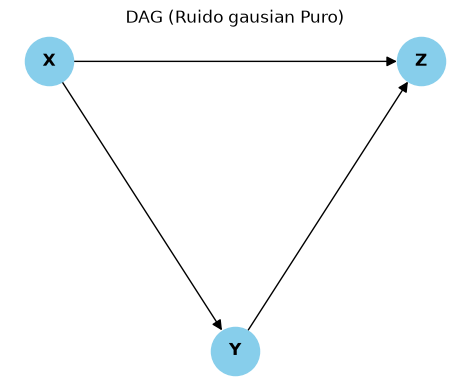


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 50
 -> Entrenando MSE para N=50 y semilla=42...
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 59
 -> Entrenando HSIC para N=50 y semilla=42...
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 182
 -> Entrenando HYBRID_ALPHA0.1 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 198
 -> Entrenando HYBRID_ALPHA0.2 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 172
 -> Entrenando HYBRID_ALPHA0.3 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 31
Using device: cpu
Early stopping at step 300
 -> Entrenando HYBRID_ALPHA0.4 para N=50 y semilla=42...
Using device: cpu

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,50,3.29331,0.65882,0.33593,91.14439,2.34497,0.27325,0.15560,0.00455,0.02157,0.625
12,1,42,hsic,HSIC,0.0,1.0,100,3.10864,0.66485,0.35160,92.12136,2.23661,0.18108,0.12699,0.00534,0.02904,0.600
23,1,42,hsic,HSIC,0.0,1.0,300,3.58952,0.78196,0.27179,93.31850,2.60431,0.13895,0.18347,0.00639,0.25834,0.800
34,1,42,hsic,HSIC,0.0,1.0,500,3.27226,0.66243,0.34206,91.32263,2.48512,0.09530,0.08505,0.00462,0.16826,0.775
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,50,3.29347,0.65888,0.33618,92.06547,2.25553,0.27517,0.15645,0.00493,0.02229,0.550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,20,61,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,1.73270,0.58634,0.38514,26.16618,1.19782,0.09145,0.06444,0.00339,0.09235,0.750
836,20,61,mse,MSE,1.0,0.0,50,3.17850,0.65237,0.35238,89.34626,2.05466,0.31576,0.13556,0.00512,0.02319,0.600
847,20,61,mse,MSE,1.0,0.0,100,2.65656,0.62184,0.33016,85.48120,2.05497,0.22168,0.12242,0.00457,0.01808,0.650
858,20,61,mse,MSE,1.0,0.0,300,3.41786,0.66884,0.34700,87.06803,1.66938,0.15379,0.09225,0.00426,0.08837,0.725


In [ ]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gamma multiplicativo (media 0, varianza escala**2)."""
    np.random.seed(seed)
    forma = 2.0  # asimetria = 2/sqrt(forma); con forma=1 la gausian seria identica a la Exponencial
    theta, media_gamma = escala / np.sqrt(forma), np.sqrt(forma) * escala
    eps_X = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    eps_Y = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    eps_Z = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    
    X = eps_X
    Y = 0.5 * (X ** 2) * eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) * eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar.
# IMPORTANTE: a partir de ahora N_actual es directamente el número de muestras de
# ENTRENAMIENTO (ya no se genera 2*N y se parte a la mitad).
valores_N_experimento = [50,100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
# 20 semillas: las 10 originales (42-51, incluyen los outliers ya observados con
# KAN α=0.3) + 10 nuevas (52-61), para ganar precisión sin descartar ninguna
# observación real (descartar las semillas con outliers sesgaría la varianza).
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                                  52, 53, 54, 55, 56, 57, 58, 59, 60, 61])

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# --- CONJUNTO DE EVALUACIÓN FIJO ---
# Para que todos los experimentos (distinto N, distinta semilla, y también el Causal
# Flow del Paso 8) sean totalmente comparables entre sí, evaluamos SIEMPRE contra las
# mismas 100 muestras, generadas una única vez aquí con una semilla propia (fuera de
# `semillas_experimento`, para que nunca coincida con ningún conjunto de entrenamiento).
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999
factual_eval_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO, escala=1.0)
datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
num_muestras_eval = len(factual_eval_d)

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido gamma Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación del conjunto de ENTRENAMIENTO con exactamente N_actual muestras.
        #    El conjunto de EVALUACIÓN es fijo (factual_eval_d / datos_reales_test /
        #    num_muestras_eval), generado una única vez en el Paso 2, y es el mismo
        #    para todas las semillas y todos los N -> resultados comparables entre sí.
        factual_train_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico sobre el conjunto de evaluación FIJO (factual_eval_d)
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "multiplicativo_gamma.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

In [ ]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # # Guardar cada tabla N en un CSV separado
    # ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_aditivo_gausian.csv")
    # if not os.path.exists("tablas"):
    #     os.makedirs("tablas")
    # df_resumen_n.to_csv(ruta_resumen_n, index=False)
    # print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 50 MUESTRAS
####################################################################################################

Tabla resumen para N=50:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,20,3.50390,0.80001,0.68746,0.06957,0.35018,...,0.27092,0.11568,0.14944,0.04741,0.00492,0.00062,0.06847,0.05711,0.66250,0.10591
0,0.0,1.0,hsic,HSIC,20,3.29410,0.48380,0.68692,0.04851,0.34331,...,0.27643,0.09159,0.16022,0.01865,0.00533,0.00032,0.08872,0.08368,0.66000,0.09047
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,3.57649,0.84753,0.69382,0.07255,0.34952,...,0.24985,0.11719,0.14037,0.04784,0.00483,0.00046,0.06689,0.05436,0.67000,0.09234
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,3.60051,1.07728,0.69302,0.07624,0.34454,...,0.22575,0.11216,0.14440,0.06467,0.00478,0.00047,0.06347,0.05620,0.66000,0.09947
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,3.56893,1.11431,0.69017,0.09115,0.34247,...,0.20164,0.10188,0.12864,0.04172,0.00453,0.00057,0.06361,0.05417,0.67250,0.10160
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,3.51808,1.22547,0.68214,0.08737,0.34003,...,0.20621,0.09168,0.12770,0.04449,0.00460,0.00047,0.05928,0.04945,0.67375,0.09049
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,3.39817,1.16088,0.66788,0.05283,0.34034,...,0.21683,0.10256,0.13605,0.04589,0.00480,0.00042,0.06280,0.05301,0.67750,0.08307
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,3.47309,1.32370,0.67479,0.05913,0.33626,...,0.22048,0.09980,0.13171,0.03646,0.00484,0.00057,0.05848,0.04360,0.66875,0.08918
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,3.36918,0.62215,0.67415,0.05175,0.34178,...,0.20812,0.09118,0.13510,0.04398,0.00484,0.00043,0.06086,0.04823,0.67125,0.07875
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,3.29934,0.44770,0.67261,0.04089,0.34725,...,0.22217,0.10098,0.13219,0.04037,0.00484,0.00055,0.06050,0.04855,0.66875,0.08731



✓ Tabla resumen guardada en: tablas/resumen_n_50_aditivo_gausian.csv



####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,20,3.17914,0.50531,0.65781,0.03551,0.33939,...,0.22597,0.14153,0.11756,0.03926,0.00456,0.00058,0.08721,0.07760,0.67000,0.07282
0,0.0,1.0,hsic,HSIC,20,3.24046,0.49131,0.70748,0.08247,0.32969,...,0.17389,0.05131,0.13229,0.02681,0.00540,0.00034,0.13129,0.09449,0.72250,0.07066
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,3.18469,0.48614,0.65792,0.03229,0.33730,...,0.19139,0.12907,0.10354,0.03727,0.00449,0.00052,0.07991,0.07747,0.65375,0.07534
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,3.16118,0.45943,0.65634,0.03023,0.33763,...,0.15076,0.10178,0.09293,0.03227,0.00433,0.00056,0.07450,0.07104,0.67125,0.06800
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,3.12345,0.52995,0.65370,0.03611,0.33989,...,0.11630,0.07292,0.08798,0.02271,0.00431,0.00044,0.07523,0.07101,0.68625,0.07093
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,3.13272,0.36948,0.65682,0.02573,0.33939,...,0.11139,0.07056,0.08725,0.02253,0.00426,0.00036,0.07676,0.07106,0.68250,0.07076
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,3.16969,0.35554,0.65951,0.02311,0.33845,...,0.11178,0.06969,0.08681,0.02153,0.00437,0.00030,0.07832,0.07135,0.69625,0.07749
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,3.17873,0.40153,0.66168,0.02552,0.33723,...,0.10192,0.03178,0.08320,0.01748,0.00438,0.00035,0.08052,0.06996,0.70375,0.07357
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,3.14984,0.44423,0.66271,0.03333,0.33701,...,0.10025,0.03076,0.08651,0.02219,0.00444,0.00035,0.08380,0.07013,0.70250,0.07250
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,3.22555,0.51506,0.67087,0.04170,0.33606,...,0.12762,0.06665,0.09794,0.02713,0.00462,0.00049,0.09370,0.07175,0.70625,0.06876



✓ Tabla resumen guardada en: tablas/resumen_n_100_aditivo_gausian.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



...

,Media ± Std
MSE Y,3.57318 ± 1.32938
MAE Y,0.67444 ± 0.04893
"HSIC(Y,X)",0.34775 ± 0.01700
MSE Z,75.70674 ± 22.66664
MAE Z,1.63887 ± 0.34194
"HSIC(Z,X)",0.09535 ± 0.08656
"HSIC(Z,Y)",0.07235 ± 0.03599
dHSIC Total,0.00381 ± 0.00083
MMD,0.11280 ± 0.10589
RF Acc,0.74375 ± 0.07428



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,3.71635 ± 1.85018
MAE Y,0.67622 ± 0.05573
"HSIC(Y,X)",0.34945 ± 0.01607
MSE Z,75.59310 ± 22.45087
MAE Z,1.61566 ± 0.28632
"HSIC(Z,X)",0.11749 ± 0.08117
"HSIC(Z,Y)",0.06977 ± 0.02324
dHSIC Total,0.00382 ± 0.00070
MMD,0.12399 ± 0.11281
RF Acc,0.74250 ± 0.08549



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,3.75181 ± 2.25479
MAE Y,0.67256 ± 0.06221
"HSIC(Y,X)",0.35063 ± 0.01734
MSE Z,80.83669 ± 13.41213
MAE Z,1.68410 ± 0.18137
"HSIC(Z,X)",0.16046 ± 0.09916
"HSIC(Z,Y)",0.07337 ± 0.02376
dHSIC Total,0.00383 ± 0.00074
MMD,0.12974 ± 0.11372
RF Acc,0.74750 ± 0.07020



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)
(Beta=1, HSIC puro, en eje derecho: subida garantizada para cada N, sin salirse de rango)

✓ Gráfica consolidada guardada: plots/bandplot_todas_N_aditivo_gausian.png



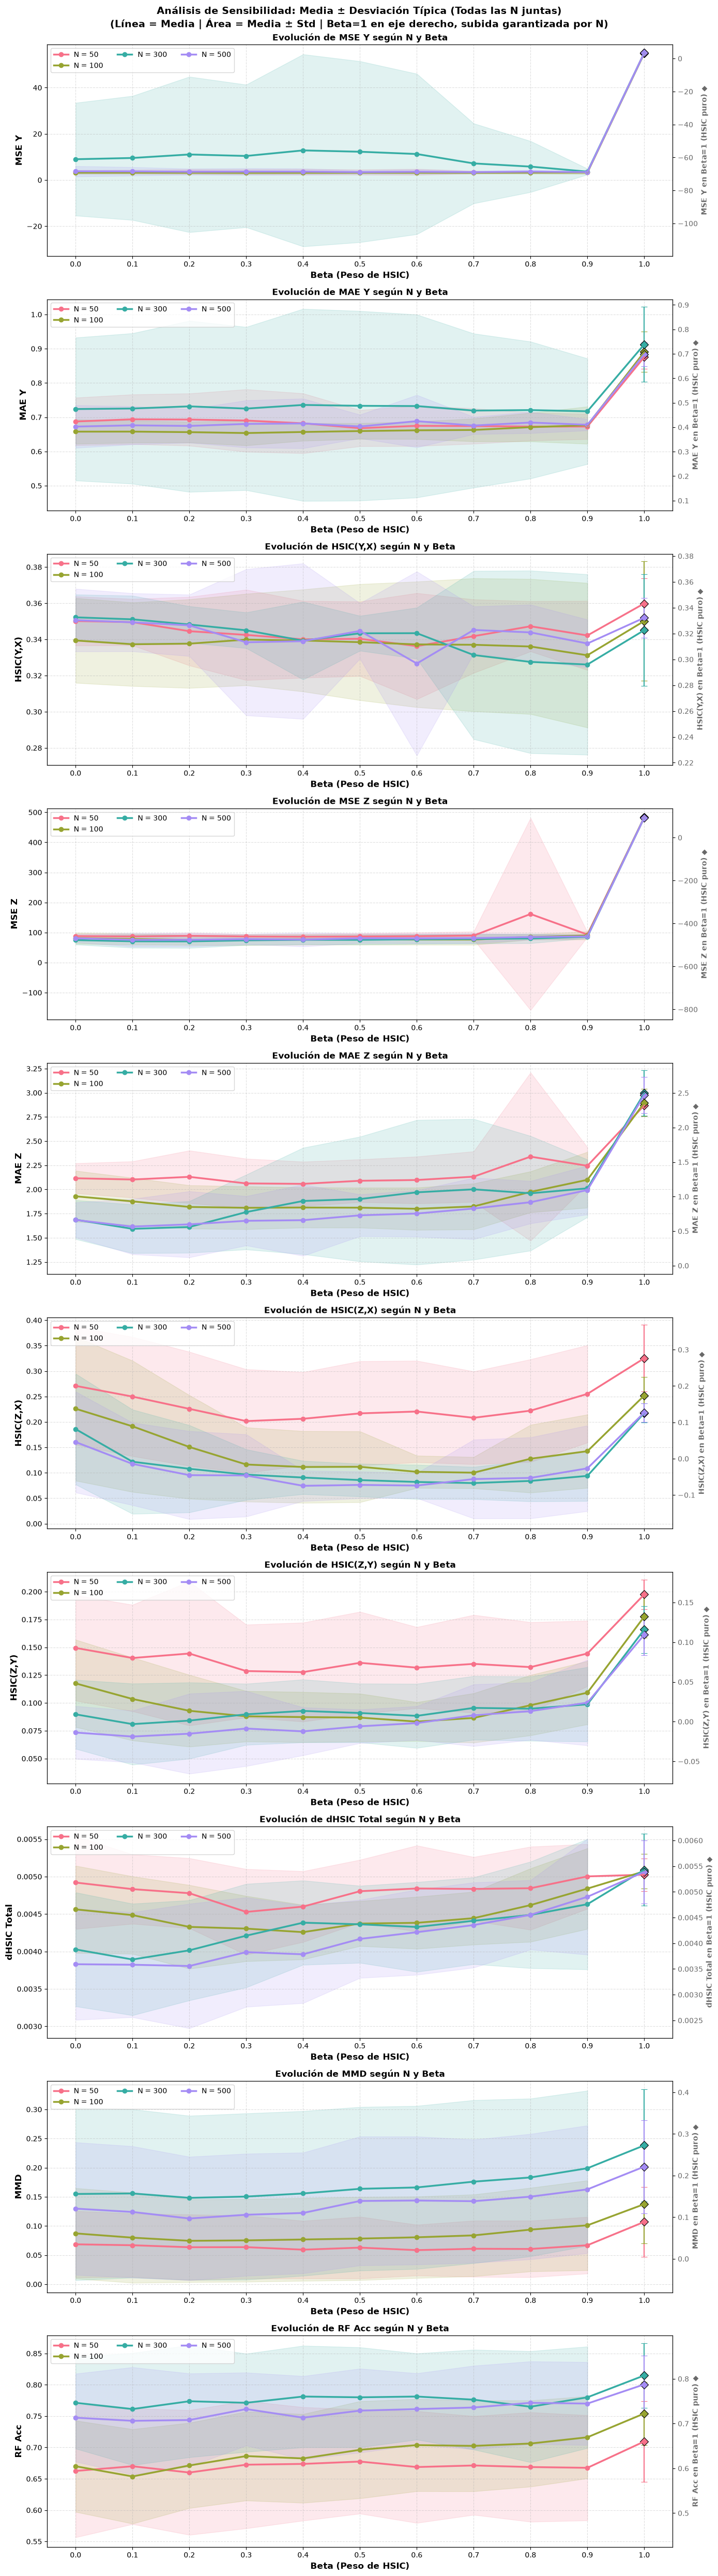

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [ ]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# Beta = 1 (HSIC puro) se pinta en un EJE Y SECUNDARIO (derecha) con su propia
# escala, para que su posible subida no comprima/deforme la escala del resto
# de Betas (0 a 0.9, eje izquierdo).
#
# TÉCNICA (v3, definitiva): el ancho del eje derecho se calcula como el MÁXIMO
# de tres necesidades:
#   1) Contención: que quepan todos los puntos de Beta=1 (con su barra de
#      error) de todas las N -> nunca se salen de rango.
#   2) Estética moderada: un mínimo de FACTOR_ANCHO_MAX veces el ancho del eje
#      izquierdo, para que la subida no parezca insignificante.
#   3) Subida garantizada por N: para CADA N cuya subida sea real (Beta=1 >
#      Beta=0.9), se calcula el ancho mínimo necesario para que esa curva en
#      concreto se vea subir en el gráfico (no solo la que domine el rango).
# Se toma el máximo de las tres, así se cumplen las tres a la vez.
#
# Si para alguna N/métrica el valor real de Beta=1 NO es mayor que el de
# Beta=0.9, la línea baja -> eso es honesto, no se fuerza a subir.
#
# Tanto la línea de conexión como la banda de ±std se recortan al área del
# propio subgráfico (`set_clip_path`) para que nunca se salgan del recuadro.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch, Polygon

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("(Beta=1, HSIC puro, en eje derecho: subida garantizada para cada N, sin salirse de rango)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std | Beta=1 en eje derecho, subida garantizada por N)', 
             fontsize=14, fontweight='bold', y=0.995)

def _a_coords_figura(fig_obj, ax_obj, punto):
    """Convierte un punto en coordenadas de datos de ax_obj a coordenadas de la figura."""
    disp = ax_obj.transData.transform(punto)
    return fig_obj.transFigure.inverted().transform(disp)

FACTOR_ANCHO_MAX = 1.4   # ancho mínimo "estético" (en veces el ancho del eje izquierdo)
MARGEN_BORDE = 0.05      # margen extra para que ningún punto quede pegado al borde

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    ax2 = ax.twinx()  # Eje secundario: SOLO para el punto Beta = 1 (HSIC puro)

    lineas_leyenda, etiquetas_leyenda = [], []
    puntos_beta1 = []  # (color, x_last, y_last, y_std_last, y1_mean, y1_std)

    # 1ª pasada: pintar Beta<1 en el eje izquierdo y recopilar los puntos de Beta=1
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        color = paleta_n[n_val]

        df_normal = df_n_data[df_n_data['Beta'] < 1.0]
        x = df_normal['Beta'].values
        y_mean = df_normal[f'{metrica}_mean'].values
        y_std = df_normal[f'{metrica}_std'].values

        linea, = ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}',
                          color=color, markersize=6)
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
        lineas_leyenda.append(linea)
        etiquetas_leyenda.append(f'N = {n_val}')

        df_beta1 = df_n_data[df_n_data['Beta'] == 1.0]
        if not df_beta1.empty and len(x) > 0:
            y1_mean = float(df_beta1[f'{metrica}_mean'].values[0])
            y1_std = float(df_beta1[f'{metrica}_std'].values[0])
            puntos_beta1.append((color, x[-1], y_mean[-1], y_std[-1], y1_mean, y1_std))

    # 2ª pasada: calcular el rango del eje derecho como el MÁXIMO de las tres
    # necesidades (contención, estética moderada, subida garantizada por N).
    bottom_ax, top_ax = ax.get_ylim()
    rango_ax = (top_ax - bottom_ax) if top_ax > bottom_ax else 1.0

    if puntos_beta1:
        techo_deseado = max(y1_mean + y1_std for _, _, _, _, y1_mean, y1_std in puntos_beta1)
        suelo_deseado = min(y1_mean - y1_std for _, _, _, _, y1_mean, y1_std in puntos_beta1)
        margen_abs = MARGEN_BORDE * max(techo_deseado - suelo_deseado, rango_ax)
        top2 = techo_deseado + margen_abs

        # 1) Contención: que quepan todos los puntos con su barra de error
        ancho_containment = (techo_deseado - suelo_deseado) + 2 * margen_abs
        # 2) Estética moderada
        ancho_moderado = FACTOR_ANCHO_MAX * rango_ax

        anchos_necesarios = [ancho_containment, ancho_moderado]

        # 3) Subida garantizada: para cada N con subida real, el ancho mínimo
        #    para que su punto quede visualmente por encima de su último punto
        for _, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
            h_last = (y_last - bottom_ax) / rango_ax
            if y1_mean > y_last and h_last < 0.999:
                cota_bottom = (y1_mean - h_last * top2) / (1 - h_last) - margen_abs
                anchos_necesarios.append(top2 - cota_bottom)

        ancho_final = max(anchos_necesarios)
        bottom2 = top2 - ancho_final
        ax2.set_ylim(bottom2, top2)

    # 3ª pasada: pintar el punto de Beta=1, y conectar tanto la media como la banda
    for color, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
        ax2.errorbar([1.0], [y1_mean], yerr=[y1_std], fmt='D', color=color,
                     markersize=8, markeredgecolor='black', markeredgewidth=0.8,
                     capsize=4, elinewidth=1.5, zorder=3)

        # Línea que conecta la media del último punto (Beta=0.9) con la de Beta=1
        con = ConnectionPatch(xyA=(x_last, y_last), coordsA=ax.transData,
                               xyB=(1.0, y1_mean), coordsB=ax2.transData,
                               color=color, linewidth=2.5, zorder=1)
        con.set_clip_path(ax.patch)  # recortar al área del propio subgráfico
        fig.add_artist(con)

        # Banda de ±std conectada entre el último punto y Beta=1
        p_inf_izq = _a_coords_figura(fig, ax, (x_last, y_last - y_std_last))
        p_inf_der = _a_coords_figura(fig, ax2, (1.0, y1_mean - y1_std))
        p_sup_der = _a_coords_figura(fig, ax2, (1.0, y1_mean + y1_std))
        p_sup_izq = _a_coords_figura(fig, ax, (x_last, y_last + y_std_last))

        banda = Polygon([p_inf_izq, p_inf_der, p_sup_der, p_sup_izq], closed=True,
                         transform=fig.transFigure, facecolor=color, alpha=0.15,
                         edgecolor=None, zorder=0)
        banda.set_clip_path(ax.patch)  # recortar al área del propio subgráfico
        fig.add_artist(banda)

    # Estética eje izquierdo (Beta 0 a 0.9)
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks(sorted(df_global['Beta'].unique()))
    ax.legend(lineas_leyenda, etiquetas_leyenda, loc='upper left', fontsize=10, ncol=3)

    # Estética eje derecho
    ax2.set_ylabel(f'{metrica} en Beta=1 (HSIC puro) ◆', fontsize=10, fontweight='bold', color='dimgray')
    ax2.tick_params(axis='y', labelcolor='dimgray')

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_multiplicativo_gamma.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")

In [ ]:
# ==============================================================================
# PASO 8: CAUSAL FLOW COMO BASELINE INDEPENDIENTE (MISMOS N Y SEMILLAS QUE EL KAN)
# ------------------------------------------------------------------------------
# Objetivo: el KAN (Pasos 2-7) muestra una desviación típica muy grande entre
# semillas. Para saber si eso es un problema propio de la arquitectura/entrenamiento
# del KAN o algo INTRÍNSECO al problema (N pequeño, ruido gamma, triángulo no
# lineal), entrenamos aquí una red completamente distinta (un normalizing flow
# causal, `causalflow_model`) con exactamente los mismos datos, N y semillas.
#
# El flow modela la densidad conjunta directamente (no tiene ecuaciones
# estructurales por nodo ni residuos explícitos), así que las métricas
# comparables "de tarta completa" son MMD y RF Acc (comparan la distribución
# generada contra los datos reales), que además ya calculábamos igual para el KAN.
#
# Igual que en el Paso 3, N_actual es el tamaño del conjunto de ENTRENAMIENTO, y la
# evaluación se hace contra el mismo conjunto FIJO (factual_eval_d / datos_reales_test
# / num_muestras_eval) definido una única vez en el Paso 2 -> comparación 100% justa
# entre KAN y Flow.
# ==============================================================================
from models import causalflow_model, default_flow_params
from copy import deepcopy

registros_flow = []

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"[CAUSAL FLOW] EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n -> [CAUSAL FLOW] N = {N_actual}, semilla = {seed}")

        # Conjunto de ENTRENAMIENTO con exactamente N_actual muestras (mismos datos que
        # el KAN para este N y esta semilla). La evaluación usa el conjunto FIJO global.
        factual_train_d = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)

        flow_params = deepcopy(default_flow_params)
        flow_params['max_epochs'] = 500          # baja esto si tarda demasiado en tu máquina
        flow_params['early_stopping_patience'] = 30

        fila = {'Experiment': experiment_id, 'Seed': seed, 'N': N_actual}

        try:
            flow_model = causalflow_model(graph_triangle, flow_params)
            historia = flow_model.fit(factual_train_d)
            fila['Best_val_nll'] = round(float(min(historia['val_nll'])), 5) if historia['val_nll'] else None

            datos_gen = flow_model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
            fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
            fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

        except Exception as e:
            print(f"   [Error en Causal Flow] N={N_actual}, semilla={seed}: {e}")

        registros_flow.append(fila)

df_flow = pd.DataFrame(registros_flow)
print("\n--- RESULTADOS CAUSAL FLOW (todas las semillas y N) ---")
display(df_flow)

carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
df_flow.to_csv(os.path.join(carpeta_tablas, "causal_flow_multiplicativo_gamma.csv"), index=False)


######################################################################
[CAUSAL FLOW] EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

 -> [CAUSAL FLOW] N = 50, semilla = 42


  0%|          | 0/500 [00:00<?, ?it/s]

 18%|█▊        | 89/500 [00:00<00:01, 209.11it/s]


Early stopping at epoch 90

 -> [CAUSAL FLOW] N = 100, semilla = 42


 20%|██        | 101/500 [00:00<00:01, 202.68it/s]


...

 38%|███▊      | 190/500 [00:01<00:01, 155.10it/s]


Early stopping at epoch 191

 -> [CAUSAL FLOW] N = 500, semilla = 61


 38%|███▊      | 192/500 [00:02<00:03, 82.99it/s]


Early stopping at epoch 193

--- RESULTADOS CAUSAL FLOW (todas las semillas y N) ---


,Experiment,Seed,N,Best_val_nll,MMD,RF Acc
0,1,42,50,2.66480,0.01935,0.750
1,1,42,100,2.13567,0.01534,0.650
2,1,42,300,2.52658,0.02524,0.525
3,1,42,500,2.21294,0.01525,0.575
4,2,43,50,3.20689,0.01442,0.675
...,...,...,...,...,...,...
75,19,60,500,12.59680,0.01870,0.525
76,20,61,50,2.56558,0.03896,0.775
77,20,61,100,2.83211,0.02776,0.675
78,20,61,300,2.99106,0.01798,0.600


In [ ]:
# ==============================================================================
# PASO 9: MEDIA ± DESVIACIÓN TÍPICA DEL CAUSAL FLOW POR N (10 SEMILLAS)
# Y COMPARACIÓN CONTRA EL KAN EN 4 PUNTOS DE SU ESPECTRO ALPHA/BETA
# (MSE puro, HYBRID alpha=0.6, HYBRID alpha=0.3, HSIC puro)
# ------------------------------------------------------------------------------
# Interpretación:
#  - Si la std del Flow es del mismo orden de magnitud que la del KAN para el
#    mismo N -> la inestabilidad es intrínseca al problema (N pequeño, ruido
#    gamma, no linealidad), no un problema específico del KAN/HSIC.
#  - Si la std del Flow es claramente menor -> apunta a que el entrenamiento
#    del KAN (inicialización, HSIC, early stopping, steps) es la fuente extra
#    de varianza y merece revisarse.
# ==============================================================================
resumen_flow = df_flow.groupby('N').agg(
    MMD_mean=('MMD', 'mean'), MMD_std=('MMD', 'std'),
    RFAcc_mean=('RF Acc', 'mean'), RFAcc_std=('RF Acc', 'std'),
).reset_index()

print("Causal Flow (baseline independiente) - Media ± Std por N:")
display(resumen_flow)

# Configs del KAN a comparar: los dos extremos (MSE, HSIC) + dos puntos intermedios
# (alpha=0.6 y alpha=0.3) en vez de solo los extremos.
configs_kan = [
    ('mse', None, 'KAN MSE'),
    ('hybrid', 0.6, 'KAN HYBRID α=0.6 (β=0.4)'),
    ('hybrid', 0.3, 'KAN HYBRID α=0.3 (β=0.7)'),
    ('hsic', None, 'KAN HSIC'),
]

registros_comparacion = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    # Fila del Flow para este N
    flow_row = resumen_flow[resumen_flow['N'] == n_val].iloc[0]
    registros_comparacion.append({
        'N': n_val, 'Config': 'Flow',
        'MMD_mean': flow_row['MMD_mean'], 'MMD_std': flow_row['MMD_std'],
        'RFAcc_mean': flow_row['RFAcc_mean'], 'RFAcc_std': flow_row['RFAcc_std'],
    })

    # Filas del KAN para cada config seleccionada
    for loss_name, alpha_val, etiqueta in configs_kan:
        grp = df_final_multi_n[(df_final_multi_n['N'] == n_val) & (df_final_multi_n['Loss'] == loss_name)]
        if alpha_val is not None:
            grp = grp[np.isclose(grp['Alpha'], alpha_val)]
        registros_comparacion.append({
            'N': n_val, 'Config': etiqueta,
            'MMD_mean': grp['MMD'].mean(), 'MMD_std': grp['MMD'].std(),
            'RFAcc_mean': grp['RF Acc'].mean(), 'RFAcc_std': grp['RF Acc'].std(),
        })

df_comparacion_larga = pd.DataFrame(registros_comparacion)

# Tabla legible: una fila por N, una columna por config, formato "media ± std"
print("\nComparación Flow vs. KAN (MSE, α=0.6, α=0.3, HSIC) — media ± std, mismo N, mismas 10 semillas:")
for n_val in sorted(df_comparacion_larga['N'].unique()):
    df_n = df_comparacion_larga[df_comparacion_larga['N'] == n_val]
    fila = {'N': n_val}
    for _, r in df_n.iterrows():
        fila[f"{r['Config']} MMD"] = f"{r['MMD_mean']:.5f} ± {r['MMD_std']:.5f}"
        fila[f"{r['Config']} RF Acc"] = f"{r['RFAcc_mean']:.5f} ± {r['RFAcc_std']:.5f}"
    display(pd.DataFrame([fila]))

# df_comparacion_larga.to_csv(os.path.join("tablas", "comparacion_flow_vs_kan_multiplicativo_gamma.csv"), index=False)

Causal Flow (baseline independiente) - Media ± Std por N:


,N,MMD_mean,MMD_std,RFAcc_mean,RFAcc_std
0,50,0.037042,0.016280,0.72750,0.050589
1,100,0.028891,0.009659,0.64375,0.077322
2,300,0.018762,0.004835,0.58750,0.058208
3,500,0.016563,0.004938,0.56625,0.042360



Comparación Flow vs. KAN (MSE, α=0.6, α=0.3, HSIC) — media ± std, mismo N, mismas 10 semillas:


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,50,0.03704 ± 0.01628,0.72750 ± 0.05059,0.06847 ± 0.05711,0.66250 ± 0.10591,0.05928 ± 0.04945,0.67375 ± 0.09049,0.06086 ± 0.04823,0.67125 ± 0.07875,0.08872 ± 0.08368,0.66000 ± 0.09047


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,100,0.02889 ± 0.00966,0.64375 ± 0.07732,0.08721 ± 0.07760,0.67000 ± 0.07282,0.07676 ± 0.07106,0.68250 ± 0.07076,0.08380 ± 0.07013,0.70250 ± 0.07250,0.13129 ± 0.09449,0.72250 ± 0.07066


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,300,0.01876 ± 0.00484,0.58750 ± 0.05821,0.15488 ± 0.14820,0.77125 ± 0.07312,0.15577 ± 0.14127,0.78125 ± 0.08106,0.17603 ± 0.13989,0.77625 ± 0.07967,0.27254 ± 0.13439,0.80750 ± 0.07214


,N,Flow MMD,Flow RF Acc,KAN MSE MMD,KAN MSE RF Acc,KAN HYBRID α=0.6 (β=0.4) MMD,KAN HYBRID α=0.6 (β=0.4) RF Acc,KAN HYBRID α=0.3 (β=0.7) MMD,KAN HYBRID α=0.3 (β=0.7) RF Acc,KAN HSIC MMD,KAN HSIC RF Acc
0,500,0.01656 ± 0.00494,0.56625 ± 0.04236,0.12974 ± 0.11372,0.74750 ± 0.07020,0.12226 ± 0.10358,0.74750 ± 0.06634,0.14245 ± 0.10573,0.76375 ± 0.06663,0.22136 ± 0.11175,0.78750 ± 0.06412


✓ Gráfica guardada: plots/boxplot_flow_vs_kan_aditivo_gausian.png


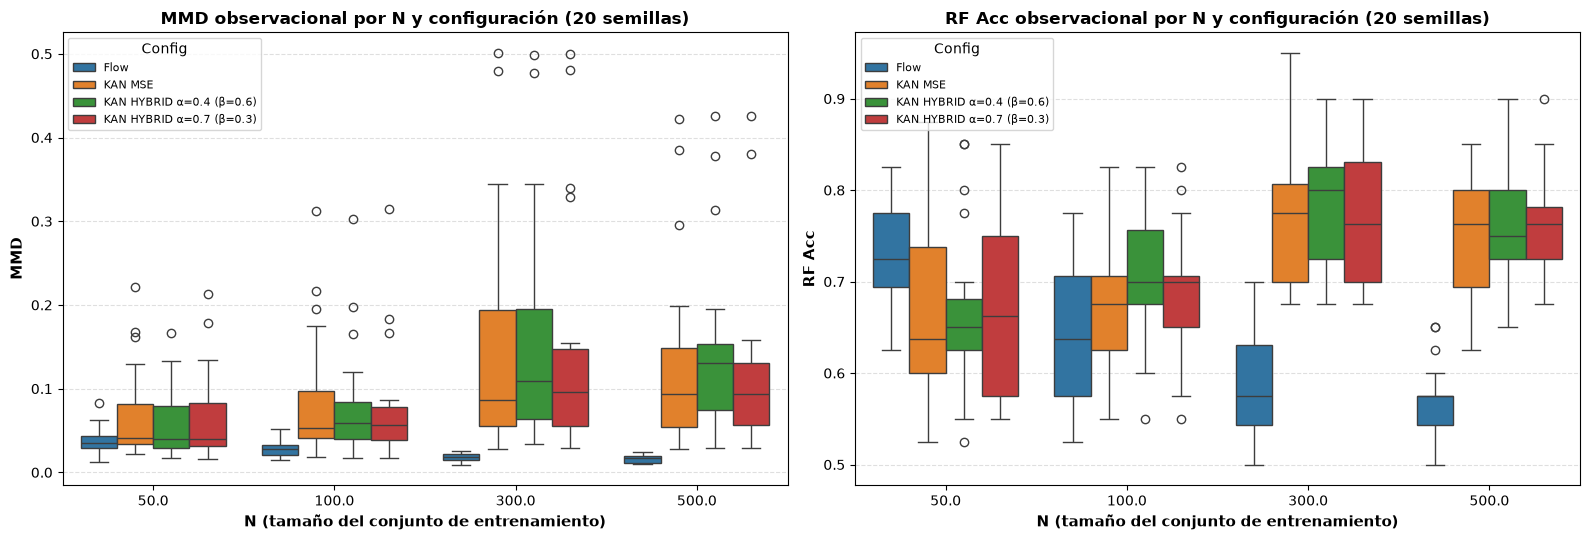

In [12]:
# ==============================================================================
# PASO 10: VISUALIZACIÓN - BOXPLOTS OBSERVACIONALES POR N Y CONFIGURACIÓN
# Un panel por métrica (MMD, RF Acc) | Eje X = N | Un color (hue) por Config
# Cada caja resume las semillas disponibles (mediana, RIC, outliers) -> mejor
# que media±std para ver si la varianza es simétrica o hay semillas concretas
# que se disparan (esto último se pierde en una banda ±std).
# ------------------------------------------------------------------------------
# Experimento puramente observacional: sin MMD/MAE interventional ni
# contrafactual (queda fuera de esta comparación a petición expresa).
# Se excluye "KAN HSIC" (β=1), igual que en el gráfico anterior.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

configs_kan_box = [
    ('mse', None, 'KAN MSE'),
    ('hybrid', 0.4, 'KAN HYBRID α=0.4 (β=0.6)'),
    ('hybrid', 0.7, 'KAN HYBRID α=0.7 (β=0.3)'),
]

registros_box = []

# Una fila por semilla para el Flow
for _, row in df_flow.iterrows():
    registros_box.append({'N': row['N'], 'Config': 'Flow', 'MMD': row['MMD'], 'RF Acc': row['RF Acc']})

# Una fila por semilla para cada config del KAN seleccionada
for loss_name, alpha_val, etiqueta in configs_kan_box:
    grp = df_final_multi_n[df_final_multi_n['Loss'] == loss_name]
    if alpha_val is not None:
        grp = grp[np.isclose(grp['Alpha'], alpha_val)]
    for _, row in grp.iterrows():
        registros_box.append({'N': row['N'], 'Config': etiqueta, 'MMD': row['MMD'], 'RF Acc': row['RF Acc']})

df_box = pd.DataFrame(registros_box)

n_semillas_usadas = df_box.groupby(['N', 'Config']).size().max()

metricas_box = ['MMD', 'RF Acc']
fig, axes = plt.subplots(1, len(metricas_box), figsize=(8 * len(metricas_box), 5.5))

for ax, metrica in zip(axes, metricas_box):
    sns.boxplot(data=df_box, x='N', y=metrica, hue='Config', ax=ax)
    ax.set_title(f'{metrica} observacional por N y configuración ({n_semillas_usadas} semillas)', fontsize=12, fontweight='bold')
    ax.set_xlabel('N (tamaño del conjunto de entrenamiento)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.legend(fontsize=8, loc='best', title='Config')

plt.tight_layout()

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot = os.path.join('plots', 'boxplot_flow_vs_kan_aditivo_gausian.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica guardada: {ruta_plot}")
plt.show()